# Linear dataset generation -- walkthrough

Tests the three coefficient structures, observation noise, and structural
error for `data_generator_funs`. Each section generates data, checks the
structure is actually what it claims to be, and plots it.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import numpy as np

from data_generator_funs.dataset import generate_linear_dataset, add_observation_noise, add_structural_error
from data_generator_funs import linear
from utils.plotting import plot_correlation, plot_data_overview, plot_scatter_examples, plot_block_structure

summary_lines = []

## Structure 1 -- full random matrix

Baseline: every output depends on every input, coefficients ~ N(0, 1). No sparsity.

coefficients shape: (10, 8)
fraction of nonzero entries: 1.0


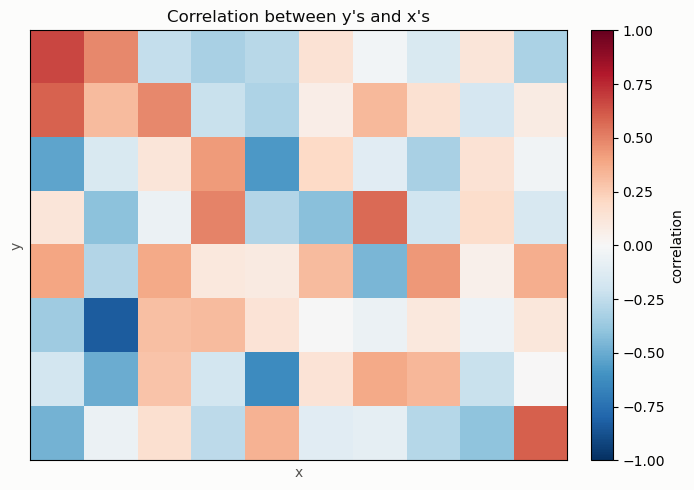

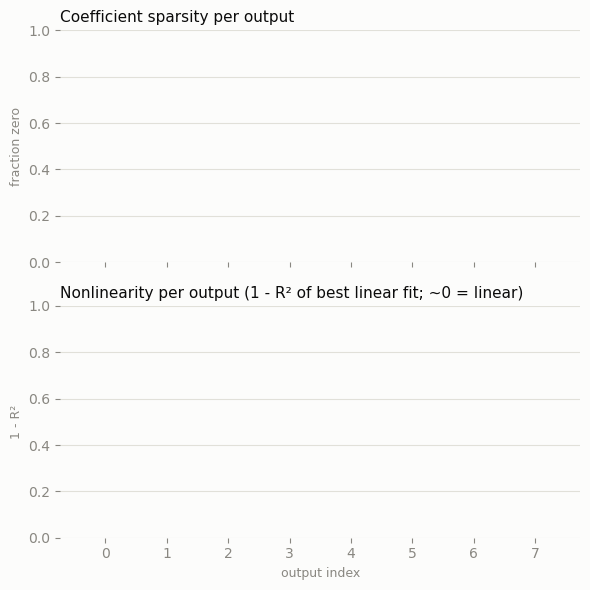

In [2]:
ds_full = generate_linear_dataset(
    n_samples=300, n_params=10, n_outputs=8, structure="full", seed=1,
)
C_full = ds_full["model_params"]["coefficients"]
print("coefficients shape:", C_full.shape)
print("fraction of nonzero entries:", (C_full != 0).mean())

_ = plot_correlation(ds_full["X"], ds_full["Y"])
_ = plot_data_overview(ds_full)

summary_lines.append(
    f"Structure 'full': {C_full.shape[0]}x{C_full.shape[1]} matrix, "
    f"{(C_full != 0).mean():.0%} nonzero (fully dense, as expected)."
)

## Structure 2 -- sliding diagonal band

`n_sensitive_para=3` means output `y_j` is driven only by params `x_j, x_{j+1}, x_{j+2}`
(e.g. `y0` <- `x0,x1,x2`; `y1` <- `x1,x2,x3`; `y2` <- `x2,x3,x4`; ...). Everything off
that band should be exactly zero.

all nonzero entries fall inside the expected band: True


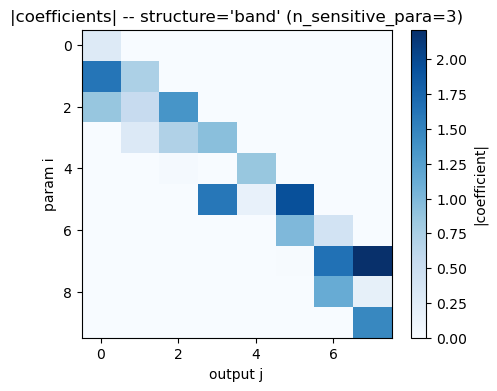

In [3]:
ds_band = generate_linear_dataset(
    n_samples=300, n_params=10, n_outputs=8, structure="band",
    structure_kwargs=dict(n_sensitive_para=3), seed=2,
)
C_band = ds_band["model_params"]["coefficients"]

fig_ok = True
for j in range(C_band.shape[1]):
    in_band = set(range(j, min(j + 3, C_band.shape[0])))
    nonzero = set(np.flatnonzero(C_band[:, j]))
    if nonzero - in_band:
        fig_ok = False
print("all nonzero entries fall inside the expected band:", fig_ok)

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(np.abs(C_band), cmap="Blues", aspect="auto")
ax.set_xlabel("output j")
ax.set_ylabel("param i")
ax.set_title("|coefficients| -- structure='band' (n_sensitive_para=3)")
fig.colorbar(im, ax=ax, label="|coefficient|")
plt.show()

summary_lines.append(
    f"Structure 'band' (n_sensitive_para=3): band check passed={fig_ok}; "
    f"{(C_band != 0).mean():.0%} nonzero overall (sparse, as expected)."
)

## Structure 3 -- block-diagonal sensitivity + small upper-triangular background

Params and outputs are split into matching groups. Each group's own diagonal
block is strongly sensitive (`sensitivity_scale`). Earlier param groups also
get a small, non-zero influence on later output groups (upper-right,
`background_scale`), while later param groups have **zero** influence on
earlier output groups (lower-left) -- no backward influence.

mean |coeff| on diagonal blocks (strong):   3.050
mean |coeff| on upper-right (small nonzero): 0.115
max  |coeff| on lower-left (should be 0):    0.000


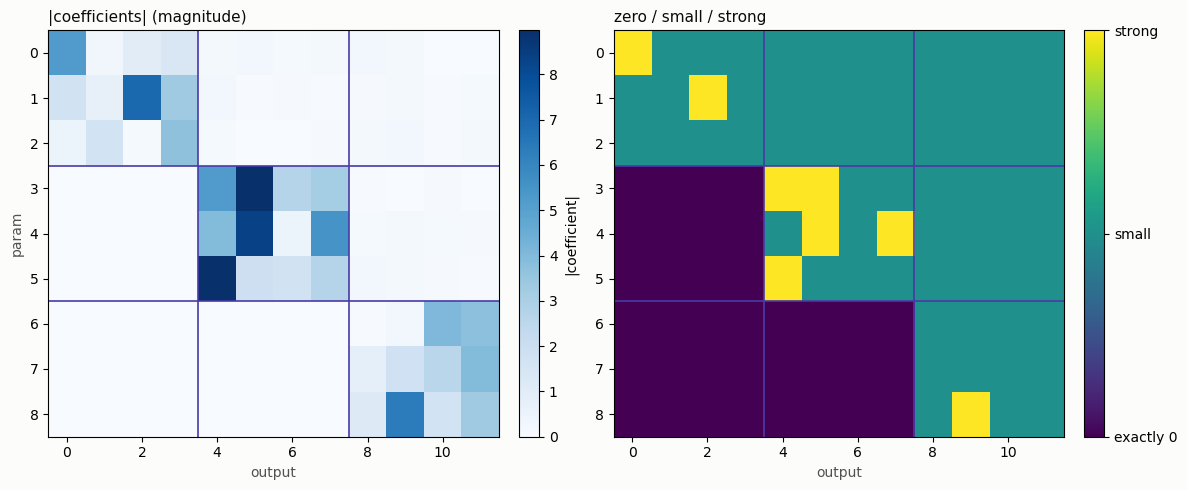

In [4]:
ds_block = generate_linear_dataset(
    n_samples=300, n_params=9, n_outputs=12, structure="block_triangular",
    structure_kwargs=dict(
        param_group_sizes=[3, 3, 3],
        output_group_sizes=[4, 4, 4],
        sensitivity_scale=4.0,
        background_scale=0.15,
    ),
    seed=3,
)
C_block = ds_block["model_params"]["coefficients"]
pg, og = ds_block["param_group_id"], ds_block["output_group_id"]

diag_mag, upper_mag, lower_mag = [], [], []
for i in range(len(pg)):
    for j in range(len(og)):
        val = abs(C_block[i, j])
        if pg[i] == og[j]:
            diag_mag.append(val)
        elif pg[i] < og[j]:
            upper_mag.append(val)
        else:
            lower_mag.append(val)

print(f"mean |coeff| on diagonal blocks (strong):   {np.mean(diag_mag):.3f}")
print(f"mean |coeff| on upper-right (small nonzero): {np.mean(upper_mag):.3f}")
print(f"max  |coeff| on lower-left (should be 0):    {np.max(lower_mag):.3f}")

_ = plot_block_structure(ds_block)

summary_lines.append(
    f"Structure 'block_triangular': diagonal mean |coeff|={np.mean(diag_mag):.2f}, "
    f"upper-right mean |coeff|={np.mean(upper_mag):.2f}, "
    f"lower-left max |coeff|={np.max(lower_mag):.2f} (exactly zero)."
)

## Observation noise

`add_observation_noise` adds i.i.d. N(0, noise_std) measurement noise to a
"true" observation. A correctly-specified model can average this out given
enough data -- it's not structural.

In [5]:
ds_noisy = generate_linear_dataset(
    n_samples=300, n_params=10, n_outputs=8, structure="full", seed=1, noise_std=0.3,
)
y_clean = ds_noisy["x_true"] @ ds_noisy["model_params"]["coefficients"]
y_noisy = ds_noisy["y_true"]

print("y_true (clean):     ", np.round(y_clean, 3))
print("y_true (with noise):", np.round(y_noisy, 3))
print("realized noise std across outputs:", np.std(y_noisy - y_clean))
print("requested noise_std:", 0.3)

summary_lines.append(
    f"Observation noise: requested std=0.30, realized std={np.std(y_noisy - y_clean):.3f} "
    f"(same generating process, y_true just gets noisier)."
)

y_true (clean):      [-2.18  -0.206  1.525  0.594 -0.736  2.207  4.626  1.465]
y_true (with noise): [-2.849  0.104  1.31   0.005 -0.609  2.504  4.443  1.793]
realized noise std across outputs: 0.3772096334993942
requested noise_std: 0.3


## Structural error

The scenario: true matrix `A`, true input `x`, `y = x @ A`. We take `y` as the
observation. Now sample a *different* input `x_b`, compute `y_b = x_b @ A`,
and replace a subset of `y`'s entries (`structural_idx`) with the matching
entries of `y_b`. Since `x_b != x`, **no single parameter vector can reproduce
every entry of the resulting observation** -- the untouched entries need `x`,
the spliced entries need `x_b`. That's what makes it structural rather than
just noisy: no amount of averaging removes it.

In [6]:
n_params, n_outputs = 10, 8
structural_idx = [5, 6, 7]  # last three outputs get the "wrong" model's values

params = {"coefficients": linear.generate_coefficients_full(n_params, n_outputs, seed=5)}
x_true = linear.sample_X(1, n_params, seed=6)[0]

y_true, x_b, y_b = add_structural_error(x_true, "linear", params, structural_idx, seed=7)

# What does the TRUE x actually predict, everywhere?
y_pred_from_x_true = linear.compute_Y(x_true[None, :], params)[0]
residual = y_pred_from_x_true - y_true

print("residual = (x_true's prediction) - y_true, per output:")
print(np.round(residual, 3))
print()
print("outputs NOT in structural_idx -- residual should be ~0:",
      np.allclose(residual[[i for i in range(n_outputs) if i not in structural_idx]], 0))
print("outputs IN structural_idx -- residual should be nonzero:",
      not np.allclose(residual[structural_idx], 0))

summary_lines.append(
    f"Structural error: on structural_idx={structural_idx}, the true x's prediction misses "
    f"y_true by up to {np.max(np.abs(residual[structural_idx])):.2f}; on every other output "
    f"the residual is exactly 0 -- no single x reproduces the whole observation."
)

residual = (x_true's prediction) - y_true, per output:
[ 0.     0.     0.     0.     0.    -5.498 -0.653  1.11 ]

outputs NOT in structural_idx -- residual should be ~0: True
outputs IN structural_idx -- residual should be nonzero: True


### Choosing how many outputs get structural error

You don't have to list the indices by hand. `n_structural=k` corrupts `k`
outputs -- by default the **last** `k` (matching "replace the last few
elements of y"), or set `structural_position="random"` to scatter them.
Use `structural_idx=[...]` instead when you want exact control.

Note `n_structural` cannot equal `n_outputs`: corrupting every output would
make `y_true` exactly `y_b`, which `x_b` reproduces perfectly -- so there'd
be no conflicting evidence left and it would stop being structural error.

In [7]:
# Same request, three ways of saying it
ds_last = generate_linear_dataset(300, 10, 8, n_structural=3, seed=20)
ds_rand = generate_linear_dataset(300, 10, 8, n_structural=3, structural_position="random", seed=20)
ds_expl = generate_linear_dataset(300, 10, 8, structural_idx=[0, 3, 6], seed=20)

for label, ds in [("n_structural=3 (last)", ds_last),
                  ("n_structural=3 (random)", ds_rand),
                  ("structural_idx=[0,3,6]", ds_expl)]:
    print(f"{label:26s} -> corrupted outputs {ds['metadata']['structural_idx']}")

# Guard: corrupting every output is refused, with an explanation
try:
    generate_linear_dataset(300, 10, 8, n_structural=8, seed=20)
except ValueError as e:
    print(f"\nn_structural=8 (all outputs) -> refused: {e}")


# Sweep the count and confirm exactly k outputs end up unreachable by x_true
print("\nk  corrupted outputs        # outputs with nonzero residual")
for k in range(0, 8):
    ds = generate_linear_dataset(300, 10, 8, n_structural=k, seed=21)
    C = ds["model_params"]["coefficients"]
    residual = ds["x_true"] @ C - ds["y_true"]
    n_bad = int(np.sum(~np.isclose(residual, 0)))
    print(f"{k}  {str(ds['metadata']['structural_idx']):24s} {n_bad}")

summary_lines.append(
    "Structural error count: n_structural=k corrupts k outputs (last k by default, or "
    "structural_position='random'); swept k=0..7 and the number of unreachable outputs "
    "matched k every time. k == n_outputs is refused, since that would leave y_true == y_b."
)

n_structural=3 (last)      -> corrupted outputs [5, 6, 7]
n_structural=3 (random)    -> corrupted outputs [0, 2, 6]
structural_idx=[0,3,6]     -> corrupted outputs [0, 3, 6]

n_structural=8 (all outputs) -> refused: n_structural=8 would replace every output, leaving y_true == y_b, which x_b reproduces exactly -- that is not structural error. Use at most n_outputs - 1 = 7.

k  corrupted outputs        # outputs with nonzero residual
0  []                       0
1  [7]                      1
2  [6, 7]                   2
3  [5, 6, 7]                3
4  [4, 5, 6, 7]             4
5  [3, 4, 5, 6, 7]          5
6  [2, 3, 4, 5, 6, 7]       6
7  [1, 2, 3, 4, 5, 6, 7]    7


## A few more datasets across sizes/noise, for a quick visual spread

Same three structures, different shapes and noise levels, just to see the
generator holding up across configurations.

--- full, small, noisy ---
X: (150, 5)  Y: (150, 4)  noise_std: 0.2


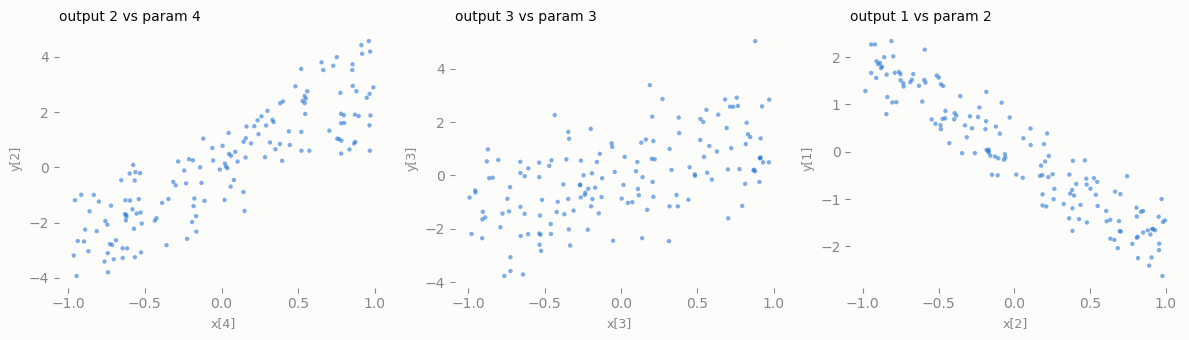

--- band, wide ---
X: (300, 20)  Y: (300, 15)  noise_std: 0.0


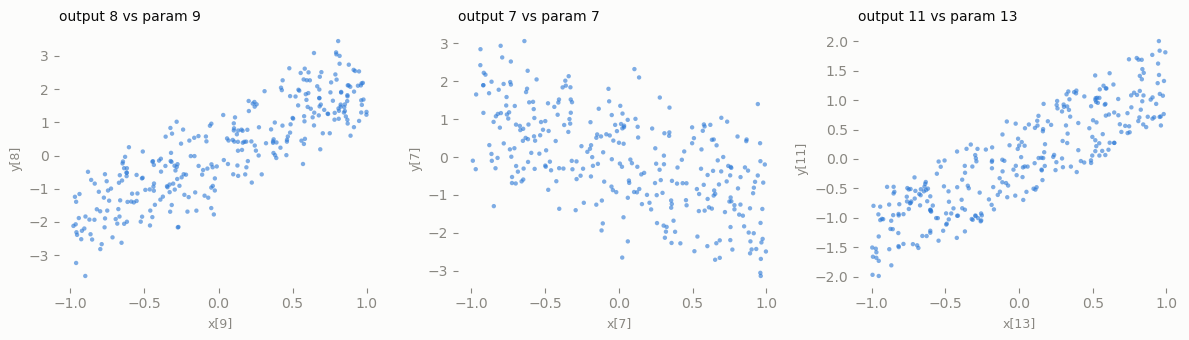

--- block_triangular, 4 groups ---
X: (300, 12)  Y: (300, 16)  noise_std: 0.0


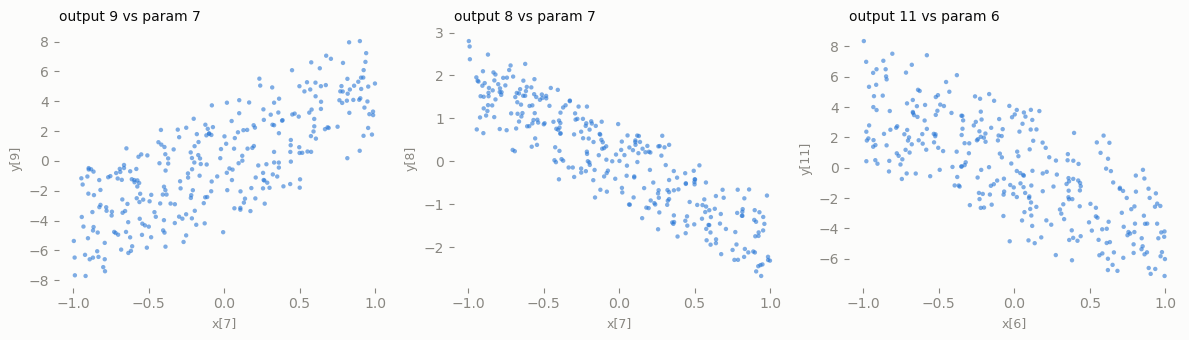

In [8]:
variants = {
    "full, small, noisy": generate_linear_dataset(
        n_samples=150, n_params=5, n_outputs=4, structure="full", noise_std=0.2, seed=10),
    "band, wide": generate_linear_dataset(
        n_samples=300, n_params=20, n_outputs=15,
        structure="band", structure_kwargs=dict(n_sensitive_para=4), seed=11),
    "block_triangular, 4 groups": generate_linear_dataset(
        n_samples=300, n_params=12, n_outputs=16, structure="block_triangular",
        structure_kwargs=dict(
            param_group_sizes=[3, 3, 3, 3], output_group_sizes=[4, 4, 4, 4],
            sensitivity_scale=3.5, background_scale=0.1),
        seed=12),
}

for name, ds in variants.items():
    print(f"--- {name} ---")
    print("X:", ds["X"].shape, " Y:", ds["Y"].shape, " noise_std:", ds["metadata"]["noise_std"])
    plot_scatter_examples(ds, n_examples=3, seed=0)

summary_lines.append(
    f"Generated {len(variants)} additional variants across sizes/noise levels "
    f"({', '.join(variants.keys())}) to sanity-check the generator holds up."
)

## Summary

In [9]:
print("What this notebook did:")
for line in summary_lines:
    print(f" - {line}")

What this notebook did:
 - Structure 'full': 10x8 matrix, 100% nonzero (fully dense, as expected).
 - Structure 'band' (n_sensitive_para=3): band check passed=True; 30% nonzero overall (sparse, as expected).
 - Structure 'block_triangular': diagonal mean |coeff|=3.05, upper-right mean |coeff|=0.12, lower-left max |coeff|=0.00 (exactly zero).
 - Observation noise: requested std=0.30, realized std=0.377 (same generating process, y_true just gets noisier).
 - Structural error: on structural_idx=[5, 6, 7], the true x's prediction misses y_true by up to 5.50; on every other output the residual is exactly 0 -- no single x reproduces the whole observation.
 - Structural error count: n_structural=k corrupts k outputs (last k by default, or structural_position='random'); swept k=0..7 and the number of unreachable outputs matched k every time. k == n_outputs is refused, since that would leave y_true == y_b.
 - Generated 3 additional variants across sizes/noise levels (full, small, noisy, band, w